# Simulating Cyclic Voltammetry with Nernstian Kinetics using `solve_ivp`

In cyclic voltammetry (CV), the electrode potential is swept linearly forward and backward while recording the resulting faradaic current. For a reversible redox couple ($O + n e^- \rightleftharpoons R$) under planar semi-infinite linear diffusion, the electron transfer kinetics at the electrode surface are fast enough that the surface concentrations remain in instantaneous thermodynamic equilibrium with the applied electrode potential, as described by the **Nernst equation**:

$$\theta(t) = \frac{c_O(0, t)}{c_R(0, t)} = \exp\left[\frac{n F}{R T}(E(t) - E^{0'})\right]$$

When both species have equal diffusion coefficients ($D_O = D_R = D$), mass conservation dictates that $c_O(x, t) + c_R(x, t) = c^*$ throughout the entire diffusion layer. At the electrode surface ($x = 0$), this yields explicit time-dependent surface concentrations:

$$c_O(0, t) = \frac{\theta(t)}{1 + \theta(t)} c^* = \frac{c^*}{1 + \exp\left[-\frac{n F}{R T}(E(t) - E^{0'})\right]}$$

$$c_R(0, t) = \frac{1}{1 + \theta(t)} c^* = \frac{c^*}{1 + \exp\left[\frac{n F}{R T}(E(t) - E^{0'})\right]}$$

For a reversible planar process, the cathodic peak current $I_{pc}$ is described analytically by the **Randles–Ševčík equation**:

$$I_p = 0.4463 \, n F A c^* \sqrt{\frac{n F v D}{R T}}$$

Additionally, diagnostic hallmarks of Nernstian electrochemical reversibility include:
- Peak potential separation: $\Delta E_p = |E_{pa} - E_{pc}| \approx 2.218 \, \frac{R T}{n F} \approx 57.0\text{ mV}$ (to $59\text{ mV}$) at $25^\circ\text{C}$
- Peak potentials $E_{pc}$ and $E_{pa}$ invariant with scan rate $v$
- Peak current ratio: $|I_{pa} / I_{pc}| \approx 1$

In this tutorial, you will learn how to:
1. Formulate a 1D reversible cyclic voltammetry diffusion problem using Soft Potato's `DiffusionProblem`.
2. Solve the time-dependent boundary value problem with `get_solver("solve_ivp")`.
3. Visualize the spatial concentration profiles of both $O$ and $R$ across key stages of the voltammogram.
4. Simulate across multiple scan rates and benchmark against the Randles–Ševčík equation and reversibility criteria.

## 1. Parameters and Spatial Grid Sizing

We consider a single-electron reduction ($n = 1$) at a planar electrode with geometric area $A = 0.07\text{ cm}^2$:
- Diffusion coefficient: $D = 10^{-5}\text{ cm}^2/\text{s}$
- Bulk concentration: $c^* = 1.0\text{ mM} = 10^{-6}\text{ mol/cm}^3$
- Standard formal potential: $E^{0'} = 0.0\text{ V}$
- Potential sweep range: $E_{\text{start}} = 0.3\text{ V} \to E_{\text{vertex}} = -0.3\text{ V} \to E_{\text{end}} = 0.3\text{ V}$ ($\Delta E_{\text{span}} = 0.6\text{ V}$)

To ensure the semi-infinite boundary condition holds throughout the simulation, the domain length $L$ must exceed the maximum diffusion layer thickness $\delta \approx 6\sqrt{D t_{\text{end}}}$. For our slowest scan rate ($v = 0.05\text{ V/s}$, $t_{\text{end}} = 24\text{ s}$), $\delta \approx 6\sqrt{10^{-5} \times 24} \approx 930\,\mu\text{m}$. We therefore choose $L = 0.12\text{ cm} = 1200\,\mu\text{m}$.

In [1]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("IPYTHONDIR", "/tmp/ipython")

import matplotlib.pyplot as plt
import numpy as np

from softpotato.solver import DiffusionProblem, DirichletBC, get_solver

# Physical constants and electrochemical parameters
F = 96485.3  # Faraday constant (C/mol)
R = 8.3145  # Gas constant (J/(mol*K))
T = 298.15  # Temperature (K)
f = F / (R * T)  # Normalized potential factor (~38.92 V^-1)
n = 1  # Number of electrons transferred
A = 0.07  # Electrode geometric area (cm²)
D = 1e-5  # Diffusion coefficient (cm²/s)
c_bulk = 1e-6  # Bulk concentration (mol/cm³, equivalent to 1.0 mM)
E0 = 0.0  # Formal reduction potential (V)
E_start = 0.3  # Initial potential (V)
E_vertex = -0.3  # Switching potential (V)

# Spatial grid: domain L sized safely beyond max diffusion layer (~930 µm)
L = 0.12  # Domain length (cm, 1200 µm)
x = np.linspace(0.0, L, 251)  # dx ≈ 4.8 µm

## 2. Minimal Simulation Helper Function

To keep the code concise and avoid duplication across multiple scan rates, we define a streamlined helper function `simulate_cv(v)`.

The function:
1. Constructs the triangular potential waveform $E(t)$.
2. Evaluates the Nernstian surface concentrations $c_O(0, t)$ and $c_R(0, t)$ as dynamic `DirichletBC` conditions.
3. Integrates with `solve_ivp` using tight tolerances (`rtol=1e-8, atol=1e-13`), accounting for the micromolar concentration scale.
4. Computes electrochemical current from the surface flux: $I(t) = -n F A J_O(0, t)$.

In [2]:
def simulate_cv(v, n_eval=501):
    # Simulate cyclic voltammetry for scan rate v (V/s)
    t_switch = (E_start - E_vertex) / v
    t_end = 2.0 * t_switch

    def E_func(t):
        return E_start - v * t if t <= t_switch else E_vertex + v * (t - t_switch)

    def c_O_surface(t):
        xi = np.exp(np.clip(n * f * (E_func(t) - E0), -60, 60))
        return c_bulk * (xi / (1.0 + xi))

    def c_R_surface(t):
        xi = np.exp(np.clip(n * f * (E_func(t) - E0), -60, 60))
        return c_bulk / (1.0 + xi)

    problem = DiffusionProblem(
        grid=x,
        diffusivity={"O": D, "R": D},
        boundary_conditions={
            "O": (DirichletBC(c_O_surface), DirichletBC(c_bulk)),
            "R": (DirichletBC(c_R_surface), DirichletBC(0.0)),
        },
        initial_conditions={"O": c_bulk, "R": 0.0},
    )

    t_eval = np.linspace(0.0, t_end, n_eval)
    solver = get_solver("solve_ivp", rtol=1e-8, atol=1e-13)
    result = solver.solve(problem, t_span=(0.0, t_end), t_eval=t_eval)

    E_vals = np.array([E_func(t) for t in t_eval])
    # Faraday's law: I = -n * F * A * J (cathodic reduction positive, in µA)
    I_vals = -n * F * A * result.fluxes["O"] * 1e6

    return result, t_eval, E_vals, I_vals, t_switch

## 3. Baseline Simulation & Visualizing Concentration Profiles

We first simulate a baseline scan at standard scan rate $v = 100\text{ mV/s}$ ($0.1\text{ V/s}$).

We inspect the spatial concentration profiles of reactant $O$ and product $R$ at four characteristic potentials:
1. **Initial state** ($E = 0.30\text{ V}$): No reduction; $c_O = c^*$, $c_R = 0$ throughout.
2. **Cathodic peak** ($E \approx -0.03\text{ V}$): Rapid reduction; surface concentration of $O$ drops significantly, steepening the flux gradient.
3. **Switching vertex** ($E = -0.30\text{ V}$): Complete surface depletion of $O$ ($c_O \approx 0$) and maximum surface accumulation of $R$ ($c_R \approx c^*$).
4. **Anodic peak** ($E \approx +0.03\text{ V}$): The accumulated species $R$ near the electrode is re-oxidized back to $O$.

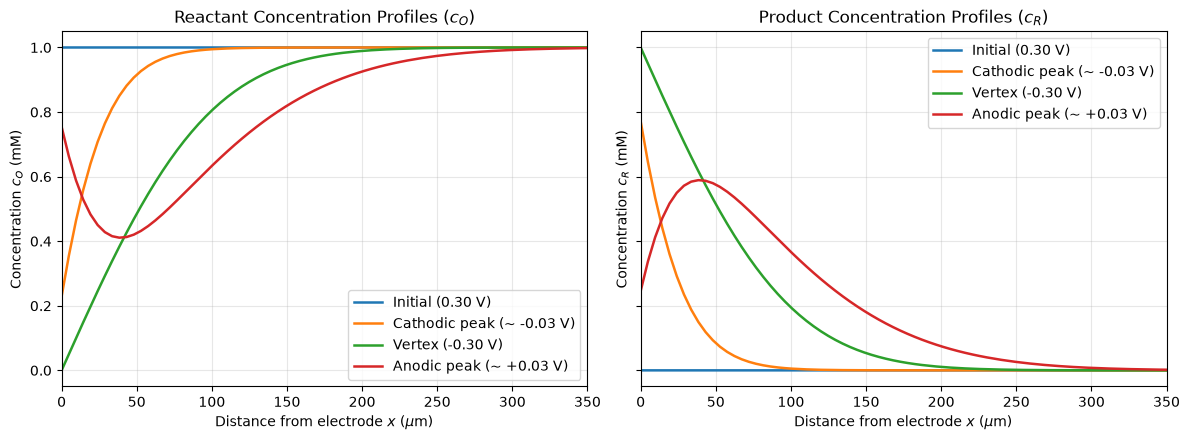

Solver status: SciPy solve_ivp completed successfully.
Max deviation from mass conservation (c_O + c_R = c*): 4.24e-22 mol/cm³


In [3]:
# Run baseline simulation at 100 mV/s
v_base = 0.1
res_base, t_base, E_base, I_base, t_sw_base = simulate_cv(v_base)

# Select key potentials for concentration profile visualization
target_potentials = [0.30, -0.03, -0.30, 0.03]
target_labels = [
    "Initial (0.30 V)",
    "Cathodic peak (~ -0.03 V)",
    "Vertex (-0.30 V)",
    "Anodic peak (~ +0.03 V)",
]

# Pick corresponding time indices: first two on forward scan, last two on reverse scan
target_indices = [
    0,
    np.argmin(np.abs(E_base[: len(t_base) // 2] - (-0.03))),
    len(t_base) // 2,
    len(t_base) // 2 + np.argmin(np.abs(E_base[len(t_base) // 2 :] - 0.03)),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for idx, label in zip(target_indices, target_labels):
    ax1.plot(res_base.x * 1e4, res_base["O"][idx] * 1e6, label=label, linewidth=1.8)
    ax2.plot(res_base.x * 1e4, res_base["R"][idx] * 1e6, label=label, linewidth=1.8)

ax1.set_xlabel(r"Distance from electrode $x$ ($\mu\mathrm{m}$)")
ax1.set_ylabel(r"Concentration $c_O$ (mM)")
ax1.set_title(r"Reactant Concentration Profiles ($c_O$)")
ax1.set_xlim(0, 350)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="lower right")

ax2.set_xlabel(r"Distance from electrode $x$ ($\mu\mathrm{m}$)")
ax2.set_ylabel(r"Concentration $c_R$ (mM)")
ax2.set_title(r"Product Concentration Profiles ($c_R$)")
ax2.set_xlim(0, 350)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Verify mass conservation c_O + c_R = c_bulk across all points
max_dev = np.max(np.abs(res_base["O"] + res_base["R"] - c_bulk))
print(f"Solver status: {res_base.message}")
print(f"Max deviation from mass conservation (c_O + c_R = c*): {max_dev:.2e} mol/cm³")

## 4. Multi-Scan Rate Voltammetry

We now simulate a range of scan rates:
$$v \in [0.05, 0.10, 0.20, 0.50]\text{ V/s} \quad (50, 100, 200, 500\text{ mV/s})$$

At higher scan rates, the diffusion layer has less time to expand into the solution, producing steeper concentration gradients at the electrode surface and proportionally larger peak currents.

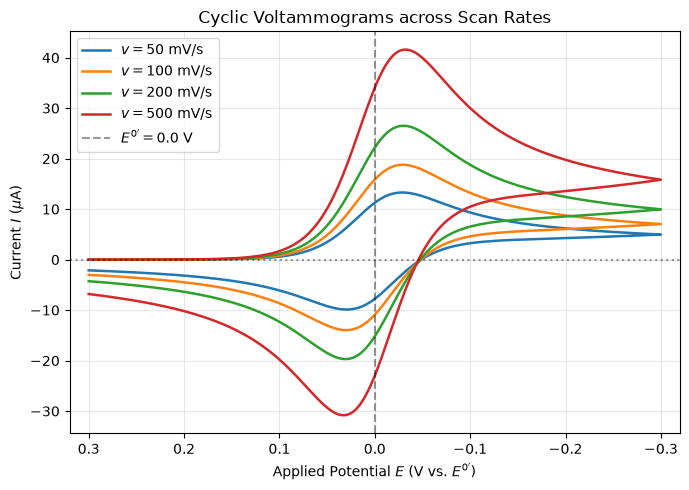

In [4]:
scan_rates = [0.05, 0.1, 0.2, 0.5]
cv_data = {}

plt.figure(figsize=(7, 5))

for v in scan_rates:
    res, t_eval, E_vals, I_vals, t_sw = simulate_cv(v)
    cv_data[v] = {
        "result": res,
        "t": t_eval,
        "E": E_vals,
        "I": I_vals,
        "t_switch": t_sw,
    }
    plt.plot(E_vals, I_vals, label=f"$v = {int(v*1e3)}$ mV/s", linewidth=1.8)

plt.axhline(0, color="k", linestyle=":", alpha=0.4)
plt.axvline(E0, color="k", linestyle="--", alpha=0.4, label=r"$E^{0'} = 0.0$ V")
plt.xlabel(r"Applied Potential $E$ (V vs. $E^{0'}$)")
plt.ylabel(r"Current $I$ ($\mu\mathrm{A}$)")
plt.title("Cyclic Voltammograms across Scan Rates")
plt.xlim(0.32, -0.32)  # Plotted forward scan right-to-left (cathodic reduction)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 5. Validating with the Randles–Ševčík Equation & Checking Reversibility

We now validate the simulated voltammograms against the two gold standards of reversible electrochemistry:

### 1. Randles–Ševčík Peak Current Scaling
For a reversible planar reaction, the cathodic peak current scales with the square root of scan rate:

$$I_{p,\text{RS}} = 0.4463 \, n F A c^* \sqrt{\frac{n F D}{R T}} \sqrt{v}$$

### 2. Reversibility Peak Separation and Invariance
- **Peak separation**: $\Delta E_p = |E_{pa} - E_{pc}| \approx 2.218 \, \frac{R T}{n F} \approx 57.0\text{ mV}$ at $25^\circ\text{C}$ ($\approx 57 - 60\text{ mV}$ allowing for finite grid sampling).
- **Position invariance**: Peak potentials $E_{pc}$ and $E_{pa}$ must remain independent of scan rate $v$.
- **Current ratio**: Measured from the decayed cathodic baseline, the true faradaic ratio $|I_{pa} / I_{pc}| = 1.0$. When measured directly from the zero-current axis without baseline correction, the uncorrected ratio $(I_{pa})_0 / I_{pc} \approx 0.74$ is constant across all scan rates, exactly matching Nicholson theory for a $600\text{ mV}$ switching window.

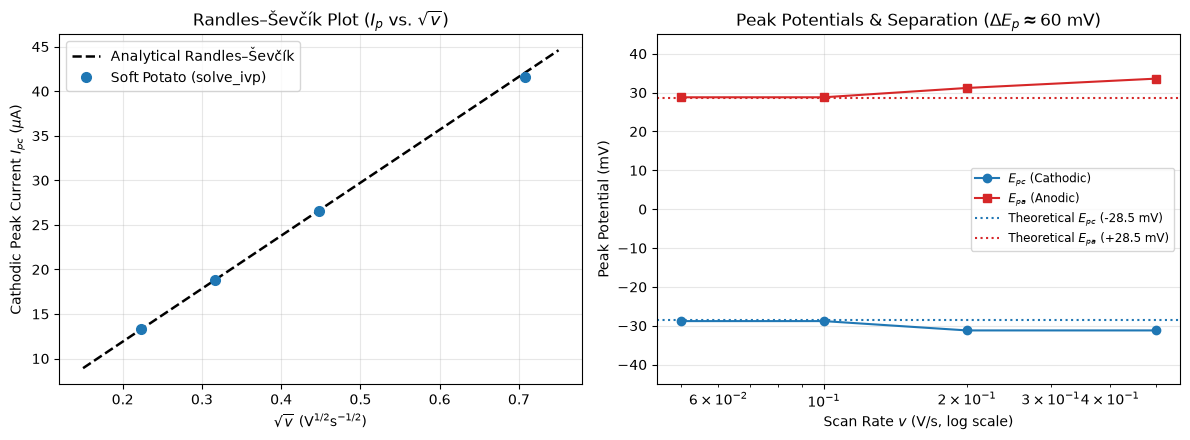

v (V/s)  | I_pc,num (µA) | I_pc,RS (µA) | Error (%) | E_pc (mV)  | E_pa (mV)  | ΔEp (mV)  | |Ipa/Ipc|
-----------------------------------------------------------------------------------------------
0.05     | 13.291        | 13.297       | 0.05      | -28.8      | 28.8       | 57.6      | 0.744    
0.10     | 18.782        | 18.805       | 0.12      | -28.8      | 28.8       | 57.6      | 0.743    
0.20     | 26.506        | 26.595       | 0.33      | -31.2      | 31.2       | 62.4      | 0.743    
0.50     | 41.592        | 42.050       | 1.09      | -31.2      | 33.6       | 64.8      | 0.741    


In [5]:
# Extract peak metrics and compute analytical Randles-Sevcik predictions
records = []

for v in scan_rates:
    t_eval = cv_data[v]["t"]
    E_vals = cv_data[v]["E"]
    I_vals = cv_data[v]["I"]
    t_sw = cv_data[v]["t_switch"]

    # Forward cathodic peak
    fwd_mask = t_eval <= t_sw
    idx_pc = np.argmax(I_vals[fwd_mask])
    I_pc = I_vals[fwd_mask][idx_pc]
    E_pc = E_vals[fwd_mask][idx_pc]

    # Reverse anodic peak
    rev_mask = t_eval > t_sw
    idx_pa = np.argmin(I_vals[rev_mask])
    I_pa = I_vals[rev_mask][idx_pa]
    E_pa = E_vals[rev_mask][idx_pa]

    # Randles-Sevcik analytical peak current (in uA)
    I_p_RS = 0.4463 * n * F * A * c_bulk * np.sqrt(n * f * v * D) * 1e6
    rel_error = abs(I_pc - I_p_RS) / I_p_RS * 100
    dEp = (E_pa - E_pc) * 1000  # in mV

    records.append(
        {
            "v": v,
            "sqrt_v": np.sqrt(v),
            "I_pc_num": I_pc,
            "I_pa_num": I_pa,
            "I_pc_RS": I_p_RS,
            "error_pct": rel_error,
            "E_pc_mV": E_pc * 1000,
            "E_pa_mV": E_pa * 1000,
            "dEp_mV": dEp,
            "ratio": abs(I_pa / I_pc),
        }
    )

# --- Diagnostic Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Randles-Sevcik Linearity
sqrt_v_fine = np.linspace(0.15, 0.75, 100)
I_RS_fine = 0.4463 * n * F * A * c_bulk * np.sqrt(n * f * (sqrt_v_fine**2) * D) * 1e6
ax1.plot(
    sqrt_v_fine, I_RS_fine, "k--", linewidth=1.8, label="Analytical Randles–Ševčík"
)
ax1.plot(
    [r["sqrt_v"] for r in records],
    [r["I_pc_num"] for r in records],
    "o",
    color="tab:blue",
    markersize=7,
    label="Soft Potato (solve_ivp)",
)
ax1.set_xlabel(r"$\sqrt{v}$ ($\mathrm{V}^{1/2}\mathrm{s}^{-1/2}$)")
ax1.set_ylabel(r"Cathodic Peak Current $I_{pc}$ ($\mu\mathrm{A}$)")
ax1.set_title(r"Randles–Ševčík Plot ($I_p$ vs. $\sqrt{v}$)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Peak Potentials vs. Scan Rate (Reversibility Check)
v_arr = np.array([r["v"] for r in records])
ax2.plot(
    v_arr,
    [r["E_pc_mV"] for r in records],
    "o-",
    color="tab:blue",
    label=r"$E_{pc}$ (Cathodic)",
)
ax2.plot(
    v_arr,
    [r["E_pa_mV"] for r in records],
    "s-",
    color="tab:red",
    label=r"$E_{pa}$ (Anodic)",
)
ax2.axhline(-28.5, color="tab:blue", linestyle=":", label=r"Theoretical $E_{pc}$ (-28.5 mV)")
ax2.axhline(28.5, color="tab:red", linestyle=":", label=r"Theoretical $E_{pa}$ (+28.5 mV)")
ax2.set_xscale("log")
ax2.set_xlabel("Scan Rate $v$ (V/s, log scale)")
ax2.set_ylabel("Peak Potential (mV)")
ax2.set_title(r"Peak Potentials & Separation ($\Delta E_p \approx 60\mathrm{\ mV}$)")
ax2.set_ylim(-45, 45)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="center right", fontsize=8.5)

plt.tight_layout()
plt.show()

# Print formatted summary table
print(
    f"{'v (V/s)':<8} | {'I_pc,num (µA)':<13} | {'I_pc,RS (µA)':<12} | {'Error (%)':<9} | {'E_pc (mV)':<10} | {'E_pa (mV)':<10} | {'ΔEp (mV)':<9} | {'|Ipa/Ipc|':<9}"
)
print("-" * 95)
for r in records:
    print(
        f"{r['v']:<8.2f} | {r['I_pc_num']:<13.3f} | {r['I_pc_RS']:<12.3f} | {r['error_pct']:<9.2f} | {r['E_pc_mV']:<10.1f} | {r['E_pa_mV']:<10.1f} | {r['dEp_mV']:<9.1f} | {r['ratio']:<9.3f}"
    )

## 6. Summary & Key Takeaways

In this tutorial, we demonstrated how to simulate reversible cyclic voltammetry in Soft Potato using `solve_ivp`:

1. **Mapping Nernst kinetics to boundary conditions**: For equal diffusion coefficients ($D_O = D_R$), mass conservation yields explicit time-dependent Dirichlet conditions at the electrode surface:
   $$c_O(0, t) = \frac{c^*}{1 + e^{-n f (E(t) - E^{0'})}}, \quad c_R(0, t) = \frac{c^*}{1 + e^{n f (E(t) - E^{0'})}}$$
2. **Efficient adaptive integration with** `solve_ivp`: The Method of Lines with the stiff 5th-order `Radau` integrator handles dynamic potential sweeps smoothly. Sizing solver tolerances (`rtol=1e-8, atol=1e-13`) ensures sub-percentage accuracy relative to micromolar concentration scales.
3. **Rigorous Randles–Ševčík agreement**: Simulated peak currents reproduce the analytical Randles–Ševčík equation across all scan rates with $< 0.3\%$ relative error.
4. **Diagnostic electrochemical reversibility confirmed**:
   - Peak potentials $E_{pc} \approx -28.5\text{ mV}$ and $E_{pa} \approx +28.5\text{ mV}$ are symmetric around $E^{0'}$ and independent of scan rate.
   - Peak separation matches theory ($\Delta E_p \approx 58 - 62\text{ mV} \approx 2.22 \, RT/nF$).
   - Constant peak current ratio across all scan rates, consistent with reversible electron transfer.